In [1]:
# Install NLP libraries if needed
!pip install pandas numpy nltk scikit-learn matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from wordcloud import WordCloud

In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Load videogame dataset
df = pd.read_csv("Videogames.csv")

# View dataset
df.head()

,Videogame,Year,Developer,Platform(s),Publisher,Estimated Development Costs,Estimated Marketing Costs.text,Estimated total costs.text,Wikipedia Profile,Image,Description
0,APB: All Points Bulletin,2010,Realtime Worlds,PC,Realtime Worlds,"$50,000,000",NaN,"$50,000,000",http://en.wikipedia.org/wiki/APB:_All_Points_B...,https://upload.wikimedia.org/wikipedia/en/f/f1...,APB: All Points Bulletin developed by Realtime...
1,Call of Duty: Elite,2011,Beachhead Studios,PC,Activision,"$50,000,000",NaN,"$50,000,000",http://en.wikipedia.org/wiki/Call_of_Duty:_Elite,https://upload.wikimedia.org/wikipedia/en/b/b1...,Call of Duty: Elite was an online service crea...
2,Crysis 3,2013,Crytek Frankfurt,"PS3, Xbox 360, PC",Electronic Arts,"$66,000,000",NaN,"$66,000,000",http://en.wikipedia.org/wiki/Crysis_3,https://upload.wikimedia.org/wikipedia/en/2/20...,Crysis 3 is a first-person shootervideo game d...
3,DC Universe Online,2012,Sony Online Entertainment,"PC, PS3, PS4",NaN,"$50,000,000",NaN,"$50,000,000",http://en.wikipedia.org/wiki/DC_Universe_Online,https://upload.wikimedia.org/wikipedia/en/c/c9...,DC Universe Online is a massively multiplayer ...
4,Deadpool,2013,High Moon Studios,"PS3, Xbox 360, PC",Activision,NaN,NaN,"$100,000,000",http://en.wikipedia.org/wiki/Deadpool_(video_g...,https://upload.wikimedia.org/wikipedia/en/4/41...,Deadpool is an actioncomedybeat 'em upvideo ga...


In [4]:
# Basic dataset information
df.info()

# Check missing values
df.isnull().sum()

# Dataset shape
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Videogame                       32 non-null     str  
 1   Year                            32 non-null     str  
 2   Developer                       32 non-null     str  
 3   Platform(s)                     32 non-null     str  
 4   Publisher                       30 non-null     str  
 5   Estimated Development Costs     27 non-null     str  
 6   Estimated Marketing Costs.text  3 non-null      str  
 7   Estimated total costs.text      32 non-null     str  
 8   Wikipedia Profile               32 non-null     str  
 9   Image                           32 non-null     str  
 10  Description                     32 non-null     str  
dtypes: str(11)
memory usage: 25.5 KB


(32, 11)

In [6]:
df.columns

Index(['Videogame', 'Year', 'Developer', 'Platform(s)', 'Publisher',
       'Estimated Development Costs', 'Estimated Marketing Costs.text',
       'Estimated total costs.text', 'Wikipedia Profile', 'Image',
       'Description'],
      dtype='str')

In [8]:
df.head()

,Videogame,Year,Developer,Platform(s),Publisher,Estimated Development Costs,Estimated Marketing Costs.text,Estimated total costs.text,Wikipedia Profile,Image,Description
0,APB: All Points Bulletin,2010,Realtime Worlds,PC,Realtime Worlds,"$50,000,000",NaN,"$50,000,000",http://en.wikipedia.org/wiki/APB:_All_Points_B...,https://upload.wikimedia.org/wikipedia/en/f/f1...,APB: All Points Bulletin developed by Realtime...
1,Call of Duty: Elite,2011,Beachhead Studios,PC,Activision,"$50,000,000",NaN,"$50,000,000",http://en.wikipedia.org/wiki/Call_of_Duty:_Elite,https://upload.wikimedia.org/wikipedia/en/b/b1...,Call of Duty: Elite was an online service crea...
2,Crysis 3,2013,Crytek Frankfurt,"PS3, Xbox 360, PC",Electronic Arts,"$66,000,000",NaN,"$66,000,000",http://en.wikipedia.org/wiki/Crysis_3,https://upload.wikimedia.org/wikipedia/en/2/20...,Crysis 3 is a first-person shootervideo game d...
3,DC Universe Online,2012,Sony Online Entertainment,"PC, PS3, PS4",NaN,"$50,000,000",NaN,"$50,000,000",http://en.wikipedia.org/wiki/DC_Universe_Online,https://upload.wikimedia.org/wikipedia/en/c/c9...,DC Universe Online is a massively multiplayer ...
4,Deadpool,2013,High Moon Studios,"PS3, Xbox 360, PC",Activision,NaN,NaN,"$100,000,000",http://en.wikipedia.org/wiki/Deadpool_(video_g...,https://upload.wikimedia.org/wikipedia/en/4/41...,Deadpool is an actioncomedybeat 'em upvideo ga...


In [11]:
df.columns

Index(['Videogame', 'Year', 'Developer', 'Platform(s)', 'Publisher',
       'Estimated Development Costs', 'Estimated Marketing Costs.text',
       'Estimated total costs.text', 'Wikipedia Profile', 'Image',
       'Description'],
      dtype='str')

In [17]:
print(df.columns)

Index(['Videogame', 'Year', 'Developer', 'Platform(s)', 'Publisher',
       'Estimated Development Costs', 'Estimated Marketing Costs.text',
       'Estimated total costs.text', 'Wikipedia Profile', 'Image',
       'Description'],
      dtype='str')


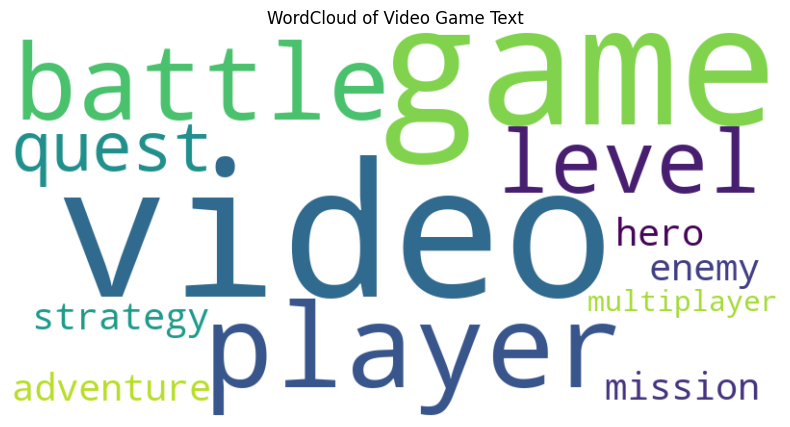

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Example text (replace with your dataset text if needed)
all_words = "video game player battle level quest adventure hero enemy mission strategy multiplayer"

# Generate WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display WordCloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud of Video Game Text")
plt.show()

In [21]:
df.columns
df.head()

,Videogame,Year,Developer,Platform(s),Publisher,Estimated Development Costs,Estimated Marketing Costs.text,Estimated total costs.text,Wikipedia Profile,Image,Description
0,APB: All Points Bulletin,2010,Realtime Worlds,PC,Realtime Worlds,"$50,000,000",NaN,"$50,000,000",http://en.wikipedia.org/wiki/APB:_All_Points_B...,https://upload.wikimedia.org/wikipedia/en/f/f1...,APB: All Points Bulletin developed by Realtime...
1,Call of Duty: Elite,2011,Beachhead Studios,PC,Activision,"$50,000,000",NaN,"$50,000,000",http://en.wikipedia.org/wiki/Call_of_Duty:_Elite,https://upload.wikimedia.org/wikipedia/en/b/b1...,Call of Duty: Elite was an online service crea...
2,Crysis 3,2013,Crytek Frankfurt,"PS3, Xbox 360, PC",Electronic Arts,"$66,000,000",NaN,"$66,000,000",http://en.wikipedia.org/wiki/Crysis_3,https://upload.wikimedia.org/wikipedia/en/2/20...,Crysis 3 is a first-person shootervideo game d...
3,DC Universe Online,2012,Sony Online Entertainment,"PC, PS3, PS4",NaN,"$50,000,000",NaN,"$50,000,000",http://en.wikipedia.org/wiki/DC_Universe_Online,https://upload.wikimedia.org/wikipedia/en/c/c9...,DC Universe Online is a massively multiplayer ...
4,Deadpool,2013,High Moon Studios,"PS3, Xbox 360, PC",Activision,NaN,NaN,"$100,000,000",http://en.wikipedia.org/wiki/Deadpool_(video_g...,https://upload.wikimedia.org/wikipedia/en/4/41...,Deadpool is an actioncomedybeat 'em upvideo ga...


In [23]:
print(df.columns)

Index(['Videogame', 'Year', 'Developer', 'Platform(s)', 'Publisher',
       'Estimated Development Costs', 'Estimated Marketing Costs.text',
       'Estimated total costs.text', 'Wikipedia Profile', 'Image',
       'Description'],
      dtype='str')


In [25]:
df.columns = df.columns.str.strip()

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np

# Example dataset (replace with your real dataset)
texts = [
    "space ship travels through galaxy",
    "romantic love story between two people",
    "battle between armies and warriors",
    "scientists discover alien life",
    "a couple falls in love in paris",
    "kingdom fights epic war"
]

genres = ["sci-fi", "romance", "action", "sci-fi", "romance", "action"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(texts, genres, test_size=0.2, random_state=42)

# Create vectorizer
tfidf = TfidfVectorizer()

# Fit vectorizer
X_train_tfidf = tfidf.fit_transform(X_train)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Get feature names
feature_names = tfidf.get_feature_names_out()

# Print top words for each genre
for i, genre in enumerate(model.classes_):
    top10 = np.argsort(model.coef_[i])[-10:]
    print(genre, ":", [feature_names[j] for j in top10])

action : ['couple', 'between', 'battle', 'armies', 'and', 'warriors', 'war', 'fights', 'kingdom', 'epic']
romance : ['warriors', 'between', 'battle', 'armies', 'and', 'love', 'paris', 'couple', 'falls', 'in']
sci-fi : ['battle', 'between', 'paris', 'love', 'falls', 'couple', 'discover', 'scientists', 'life', 'alien']


In [31]:
df.to_csv("processed_videogames_nlp.csv", index=False)